# ***Car Price Prediction Using Machine Learning Techniques***

## 1. Introduction

- To analyze the relationship between car features and their prices
 
- To identify key factors affecting car pricing (engine size, horsepower, etc.)
 
- To perform data cleaning and exploratory data analysis on the dataset
 
- To build predictive models using machine learning algorithms
 
- To compare multiple models and select the best-performing one
 
- To help businesses understand pricing dynamics for better decision-making

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
columns = [
'symboling','normalized_losses','make','fuel_type','aspiration',
'num_of_doors','body_style','drive_wheels','engine_location',
'wheel_base','length','width','height','curb_weight','engine_type',
'num_of_cylinders','engine_size','fuel_system','bore','stroke',
'compression_ratio','horsepower','peak_rpm','city_mpg','highway_mpg','price'
]

df = pd.read_csv("auto_imports.csv", names=columns)
df = df.drop(0)
df.reset_index(drop=True, inplace=True)

df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


## 2. Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          200 non-null    int64  
 1   normalized_losses  200 non-null    object 
 2   make               200 non-null    object 
 3   fuel_type          200 non-null    object 
 4   aspiration         200 non-null    object 
 5   num_of_doors       200 non-null    object 
 6   body_style         200 non-null    object 
 7   drive_wheels       200 non-null    object 
 8   engine_location    200 non-null    object 
 9   wheel_base         200 non-null    float64
 10  length             200 non-null    float64
 11  width              200 non-null    float64
 12  height             200 non-null    float64
 13  curb_weight        200 non-null    int64  
 14  engine_type        200 non-null    object 
 15  num_of_cylinders   200 non-null    object 
 16  engine_size        200 non

In [4]:
df.describe()

,symboling,wheel_base,length,width,height,curb_weight,engine_size,compression_ratio,city_mpg,highway_mpg,price
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.830000,98.848000,174.228000,65.898000,53.791500,2555.705000,126.860000,10.170100,25.200000,30.705000,13205.690000
std,1.248557,6.038261,12.347132,2.102904,2.428449,518.594552,41.650501,4.014163,6.432487,6.827227,7966.982558
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.675000,64.175000,52.000000,2163.000000,97.750000,8.575000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,119.500000,9.000000,24.000000,30.000000,10270.000000
75%,2.000000,102.400000,183.500000,66.675000,55.525000,2928.250000,142.000000,9.400000,30.000000,34.000000,16500.750000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [5]:
df.isnull().sum()

symboling            0
normalized_losses    0
make                 0
fuel_type            0
aspiration           0
num_of_doors         0
body_style           0
drive_wheels         0
engine_location      0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
engine_type          0
num_of_cylinders     0
engine_size          0
fuel_system          0
bore                 0
stroke               0
compression_ratio    0
horsepower           0
peak_rpm             0
city_mpg             0
highway_mpg          0
price                0
dtype: int64

## 3. Data Cleaning

In [6]:
df.replace("?", np.nan, inplace=True)

num_cols = ['normalized_losses','bore','stroke','horsepower','peak_rpm','price']

for col in num_cols:
    df[col] = pd.to_numeric(df[col])

df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

### Imputation Justification

- Median is used for numerical columns as it is robust to outliers and skewed distributions  
- Since the price distribution is right-skewed, median provides a better central value than mean  
- Mode is used for categorical columns as it represents the most frequent category  

## 4. Feature Engineering

In [7]:
# creating new features
df['power_to_weight'] = df['horsepower'] / df['curb_weight']
df['engine_efficiency'] = df['engine_size'] / df['horsepower']

df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price,power_to_weight,engine_efficiency
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111.0,5000.0,21,27,16500,0.043564,1.171171
1,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,2.68,3.47,9.0,154.0,5000.0,19,26,16500,0.054552,0.987013
2,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,3.19,3.40,10.0,102.0,5500.0,24,30,13950,0.043646,1.068627
3,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,3.19,3.40,8.0,115.0,5500.0,18,22,17450,0.040722,1.182609
4,2,115.0,audi,gas,std,two,sedan,fwd,front,99.8,...,3.19,3.40,8.5,110.0,5500.0,19,25,15250,0.043877,1.236364


- New features were created to capture relationships between existing variables  
- Power-to-weight ratio reflects vehicle performance  
- Engine efficiency captures engine output relative to size  

## 5. EDA

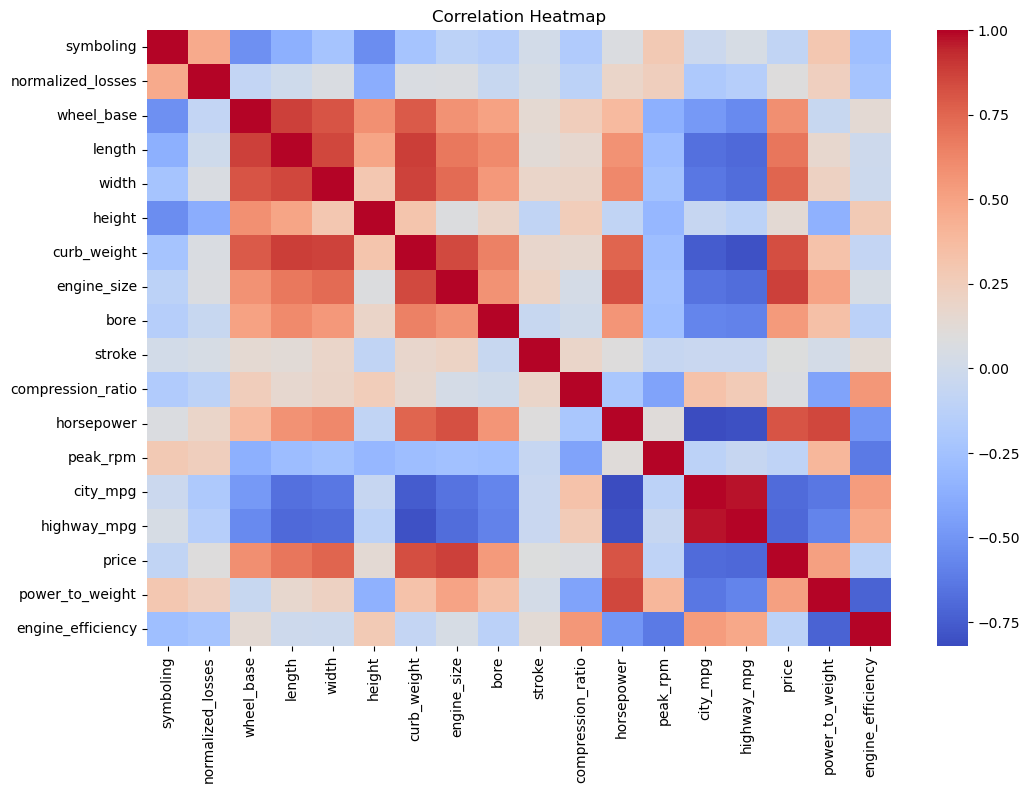

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- The heatmap shows the correlation between different numerical features in the dataset  
- Engine size, horsepower, and curb weight show strong positive correlation with price  
- This indicates that these features are key drivers of car pricing  
- Some features are also highly correlated with each other, indicating possible multicollinearity  

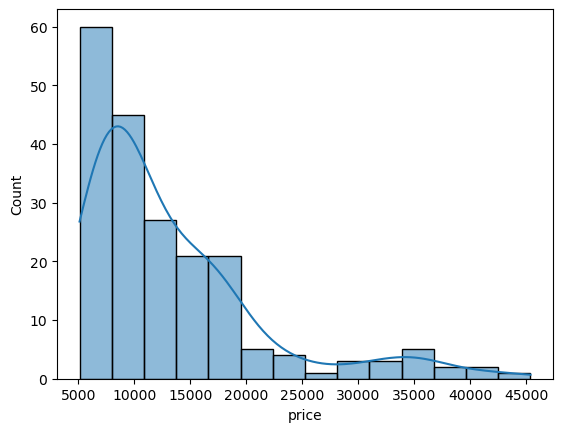

In [9]:
sns.histplot(df['price'], kde=True)
plt.show()

- The distribution of car prices is right-skewed, indicating that most cars are in the lower to mid price range  
- A few high-priced cars create a long tail on the right side  
- This suggests the presence of luxury or premium vehicles in the dataset  
- The skewness may affect model performance and indicates variability in pricing  

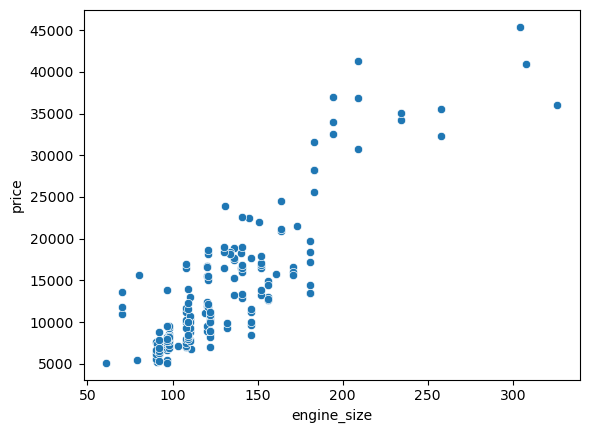

In [10]:
sns.scatterplot(x=df['engine_size'], y=df['price'])
plt.show()

- The scatter plot shows a strong positive relationship between engine size and price  
- As engine size increases, the price of the car also increases  
- This indicates that engine size is a major factor influencing car pricing  
- The relationship appears non-linear, supporting the use of advanced models like Random Forest
- The strong upward trend indicates a high positive correlation between engine size and price 

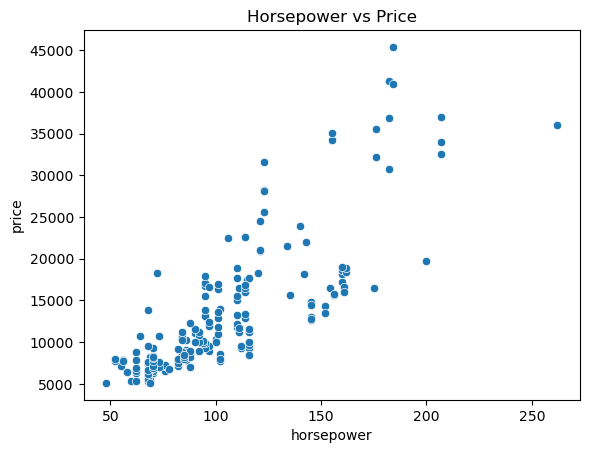

In [11]:
sns.scatterplot(x=df['horsepower'], y=df['price'])
plt.title("Horsepower vs Price")
plt.show()

- The scatter plot shows a positive relationship between horsepower and price  
- As horsepower increases, the price of the car also tends to increase  
- This indicates that cars with higher engine power are generally more expensive  
- However, some variation exists, suggesting that other factors also influence price
- The strong upward trend indicates a high positive correlation between engine size and price

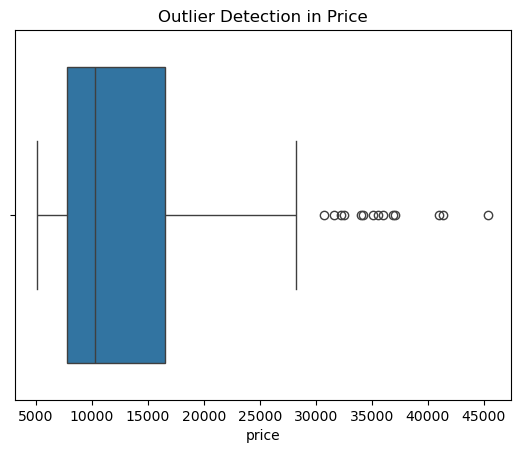

In [12]:
sns.boxplot(x=df['price'])
plt.title("Outlier Detection in Price")
plt.show()

- The boxplot shows the presence of outliers in car prices  
- A few cars have significantly higher prices compared to the rest  
- This confirms the skewness observed in the distribution plot  
- These outliers may represent luxury cars and can influence model predictions  

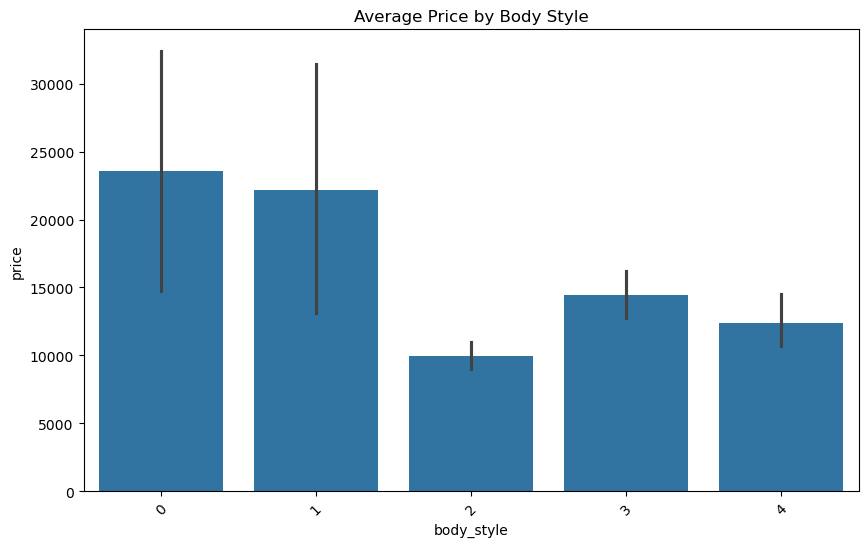

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(x='body_style', y='price', data=df)
plt.title("Average Price by Body Style")
plt.xticks(rotation=45)
plt.show()

- The bar plot shows variation in average price across different body styles  
- Certain body styles like sedans or convertibles tend to have higher average prices  
- This indicates that body style plays a role in determining car pricing  
- Categorical features also influence price and should be properly encoded  

## 6. Encoding

In [13]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

## 7. Feature Selection

In [14]:
X = df.drop("price", axis=1)
y = df["price"]

## 8. Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## 9. Scaling

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 10. Model Building

Since the target variable (price) is continuous, regression models are used for prediction  

In [17]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [18]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [19]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=3,
                    scoring='r2',
                    n_jobs=-1)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


## 11. Model Evaluation

In [21]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [22]:
models = {
    "Linear Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Tuned Random Forest": y_pred_tuned
}

results = []

for name, pred in models.items():
    mae, rmse, r2 = evaluate(y_test, pred)
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,2890.599772,4750.855590,0.798563
1,Decision Tree,1707.762500,2533.337380,0.942723
2,Random Forest,1348.467601,1894.488689,0.967968
3,Tuned Random Forest,1241.633409,1767.136807,0.972130


### Model Comparison Interpretation
- The comparison includes the tuned Random Forest model  
- The best model is selected based on lowest RMSE and highest R²  
- From the results, the top-performing model is identified  

Thus, the selected model is based on actual evaluation metrics rather than assumption.

In [23]:
print("Base Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Tuned Random Forest R2:", r2_score(y_test, y_pred_tuned))

Base Random Forest R2: 0.9679683631542636
Tuned Random Forest R2: 0.9721300978419378


### Performance Improvement Analysis
- The tuned Random Forest model is compared with the base model
- Improvement in R² indicates better performance
- This improvement is achieved through hyperparameter tuning

In [24]:
best_model = results_df.sort_values(by="RMSE").iloc[0]
best_model

Model    Tuned Random Forest
MAE              1241.633409
RMSE             1767.136807
R2                   0.97213
Name: 3, dtype: object

### Best Model Selection

Based on the evaluation metrics:

- The model with the lowest RMSE and highest R² is considered the best  
- From the results, Tuned Random Forest performs the best among all models  

Therefore, Random Forest is selected as the final model.

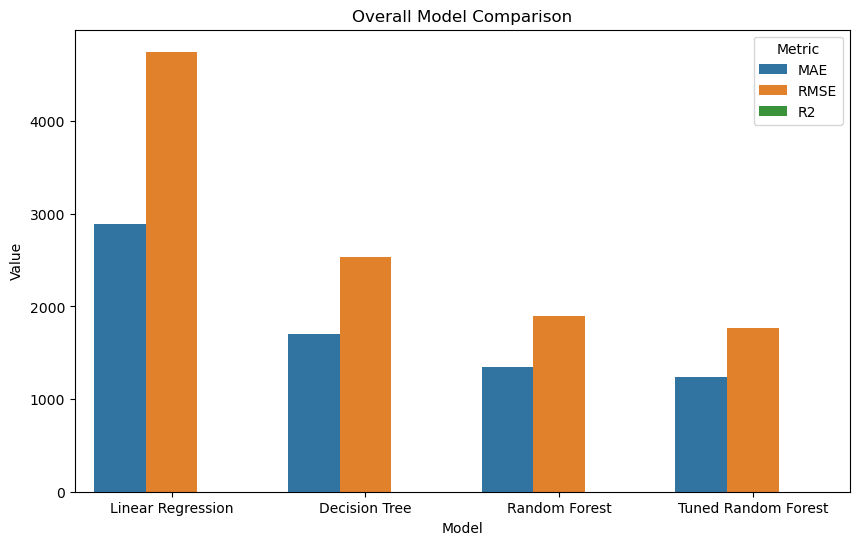

In [25]:
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Value")

plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Value", hue="Metric", data=results_melted)
plt.title("Overall Model Comparison")
plt.xticks(rotation=0)

plt.show()

- The above plot compares all models across MAE, RMSE, and R² metrics
- Lower MAE and RMSE indicate better accuracy, while higher R² indicates better model performance

## 12. Overfitting Check

In [26]:
print("Tuned RF Train Score:", best_rf.score(X_train, y_train))
print("Tuned RF Test Score:", best_rf.score(X_test, y_test))

Tuned RF Train Score: 0.9843685066617829
Tuned RF Test Score: 0.9721300978419378


### Overfitting Analysis

- Train Score: 0.984  
- Test Score: 0.972  

The small difference between training and testing scores indicates that the model is not overfitting and generalizes well to unseen data.

## 13. Feature Importance

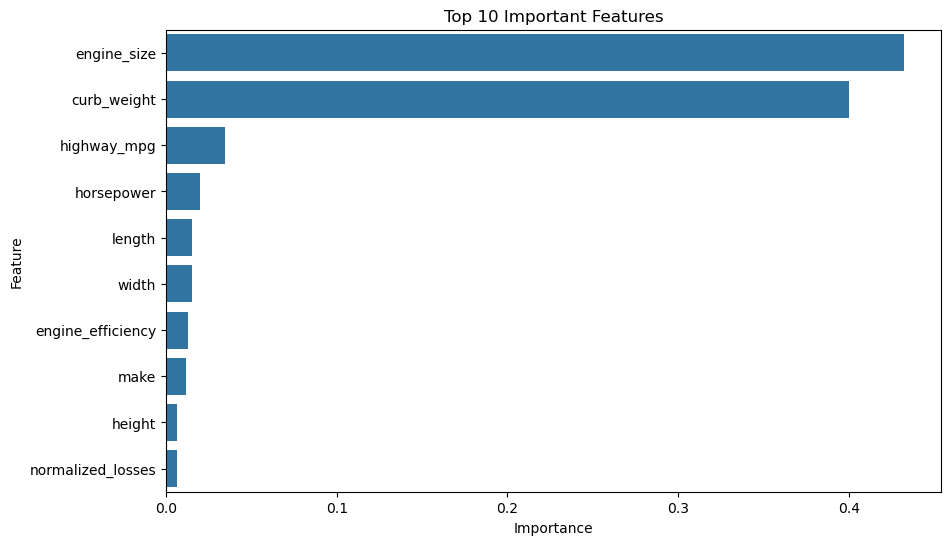

In [27]:
importances = best_rf.feature_importances_

features = X.columns
feat_df = pd.DataFrame({"Feature": features, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

- Identifies most influential variables
- Supports your conclusion scientifically
- Engineered features like power-to-weight ratio also contribute to price prediction, this shows that combining variables improves model understanding  

## 14. Project Risks and Mitigation

1. Missing Data: Could distort results

   Mitigation: Used median & mode imputation

-----

2. Overfitting: Model memorizes data

   Mitigation: Train-test split and Random Forest used

------

3. Categorical Encoding Bias: Label encoding may introduce order

   Mitigation: Could improve using One-Hot Encoding

------

4. Skewed Data: Affects model accuracy

   Mitigation: Distribution checked using histplots

------

5. Multicollinearity: Highly correlated variables

   Mitigation: Checked using heatmap

------

6. Encoding Bias: Label Encoding may introduce artificial order among categories.

Mitigation: Use One-Hot Encoding 

## 15. Business Impact

The model can help businesses:
- Understand key factors affecting car prices  
- Design vehicles according to target price segments  
- Make data-driven pricing decisions  
- Predict prices in new or competitive markets  

## 16. Final Conclusion

The project has successfully developed a machine learning model to predict car prices. Among all the models, Tuned Random Forest has performed the best with the lowest RMSE and highest R² score. Key factors influencing car prices includes engine size, horsepower, and curb weight, as identified through EDA and feature importance analysis. While the model performs well, certain limitations exist. The use of Label Encoding may introduce bias in categorical variables, and alternative techniques like One-Hot Encoding could improve the performance. Additionally, further feature engineering and advanced hyperparameter tuning can enhance the model accuracy. Overall, the model provides a reliable approach for understanding the pricing patterns and can assist businesses in making data-driven decisions.
